In [1]:
import pandas as pd
df = pd.read_csv("dados_oncologicos_completos.csv")

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/var/folders/gy/cxx2_pv95ys52g0qvnjgcsqm0000gn/T/ipykernel_5648/757949714.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dados_oncologicos_completos.csv")


In [2]:
print(f"Total casos diagnosticados: {len(df)} - nos anos {df['ANO_DIAGN'].unique()}")

Total casos diagnosticados: 4818403 - nos anos [2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


In [3]:
df['DT_DIAG'] = pd.to_datetime(df['DT_DIAG'], format='%d/%m/%Y')
df['DT_NASC'] = pd.to_datetime(df['DT_NASC'], format='%d/%m/%Y')
df['DT_TRAT'] = pd.to_datetime(df['DT_TRAT'], format='%d/%m/%Y')

In [4]:
df['DT_NASC'] = df['DT_NASC'].dt.strftime('%Y-%m-%d')

In [5]:
df['DT_DIAG'] = df['DT_DIAG'].dt.strftime('%Y-%m-%d')
df['DT_TRAT'] = df['DT_TRAT'].dt.strftime('%Y-%m-%d')

In [6]:
df = df[df['DIAG_DETH'].str.startswith(('C53'))]

In [7]:
print(f"Total casos diagnosticados: {len(df)} - nos anos {df['ANO_DIAGN'].unique()}")

Total casos diagnosticados: 159353 - nos anos [2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]


In [8]:
if "DT_DIAG" in df.columns and "DT_TRAT" in df.columns:
    df["ANO_DIAGN"] = pd.to_datetime(df["DT_DIAG"]).dt.year
    total_por_ano = df.groupby("ANO_DIAGN").size().reset_index(name="total_casos")
    df_sem_tratamento = df[df["DT_TRAT"].isna()]
    casos_sem_tratamento_por_ano = df_sem_tratamento.groupby("ANO_DIAGN").size().reset_index(name="casos_sem_tratamento")
    df_resultado = total_por_ano.merge(casos_sem_tratamento_por_ano, on="ANO_DIAGN", how="left").fillna(0)
    df_resultado["percentual_sem_tratamento"] = (df_resultado["casos_sem_tratamento"] / df_resultado["total_casos"]) * 100
    print(df_resultado)
else:
    print("As colunas 'DT_DIAG' e/ou 'DT_TRAT' não estão na base.")


    ANO_DIAGN  total_casos  casos_sem_tratamento  percentual_sem_tratamento
0        2013          161                    19                  11.801242
1        2014         1607                  1188                  73.926571
2        2015         2095                  1515                  72.315036
3        2016         2331                  1512                  64.864865
4        2017         2881                  1701                  59.041999
5        2018         7737                  3165                  40.907328
6        2019        16019                  4710                  29.402584
7        2020        18341                  4609                  25.129491
8        2021        19989                  4973                  24.878683
9        2022        21065                  5603                  26.598623
10       2023        44410                 12976                  29.218644
11       2024        19266                  6764                  35.108481
12       202

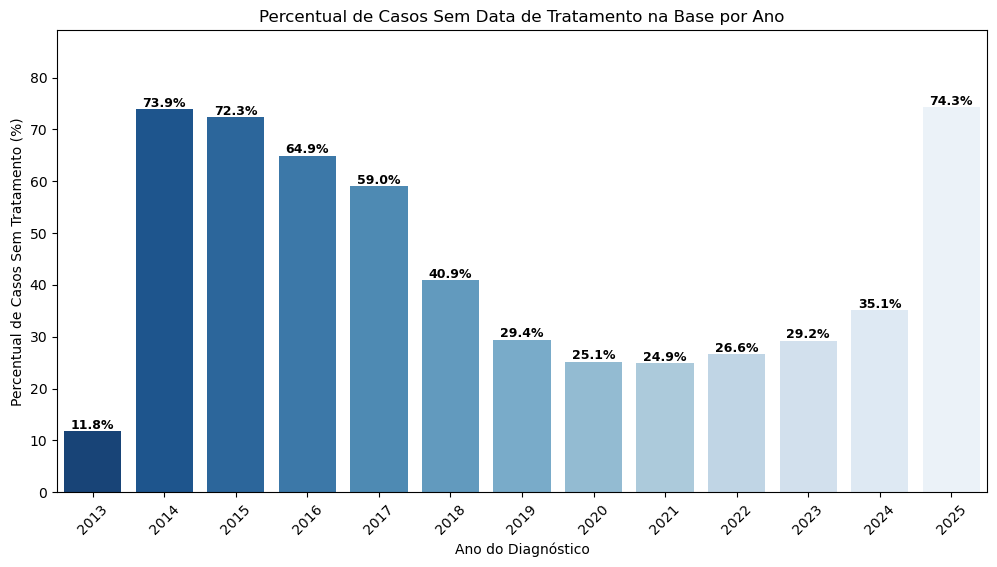

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ajustar o tamanho da figura para evitar imagens muito grandes
plt.figure(figsize=(12, 6))

# Criar o gráfico de barras
sns.barplot(data=df_resultado, x="ANO_DIAGN", y="percentual_sem_tratamento", palette="Blues_r")

# Adicionar rótulos e título
plt.xlabel("Ano do Diagnóstico")
plt.ylabel("Percentual de Casos Sem Tratamento (%)")
plt.title("Percentual de Casos Sem Data de Tratamento na Base por Ano")
plt.xticks(rotation=45)  # Rotaciona os anos para melhor visualização
plt.ylim(0, df_resultado["percentual_sem_tratamento"].max() * 1.2)  # Ajusta o limite superior do eixo Y

# Exibir os valores nas barras sem ultrapassar os limites
for index, row in df_resultado.iterrows():
    plt.text(index, row["percentual_sem_tratamento"] + 0.5, f"{row['percentual_sem_tratamento']:.1f}%", 
             ha='center', fontsize=9, fontweight='bold')

# Mostrar o gráfico
plt.show()


In [10]:
print(f"Total casos com data tratamento null: {len(df[df['DT_TRAT'].isna()])}") 

Total casos com data tratamento null: 51298


In [11]:
len(df)

159353

In [12]:
df.to_csv("../../dados_oncologicos_filtrados.csv")

In [14]:
df['ANO_DIAGN'].unique()

array([2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023,
       2024, 2025], dtype=int32)